In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.datasets import make_blobs
import ipywidgets as widgets
from IPython.display import display
from scipy.spatial import ConvexHull


import warnings
warnings.filterwarnings("ignore")



/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/homebrew/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
# Generate synthetic data
X, _ = make_blobs(n_samples=1000, centers=10, cluster_std=1.2, random_state=42)

## Agglomerative Hierarchical clustering 

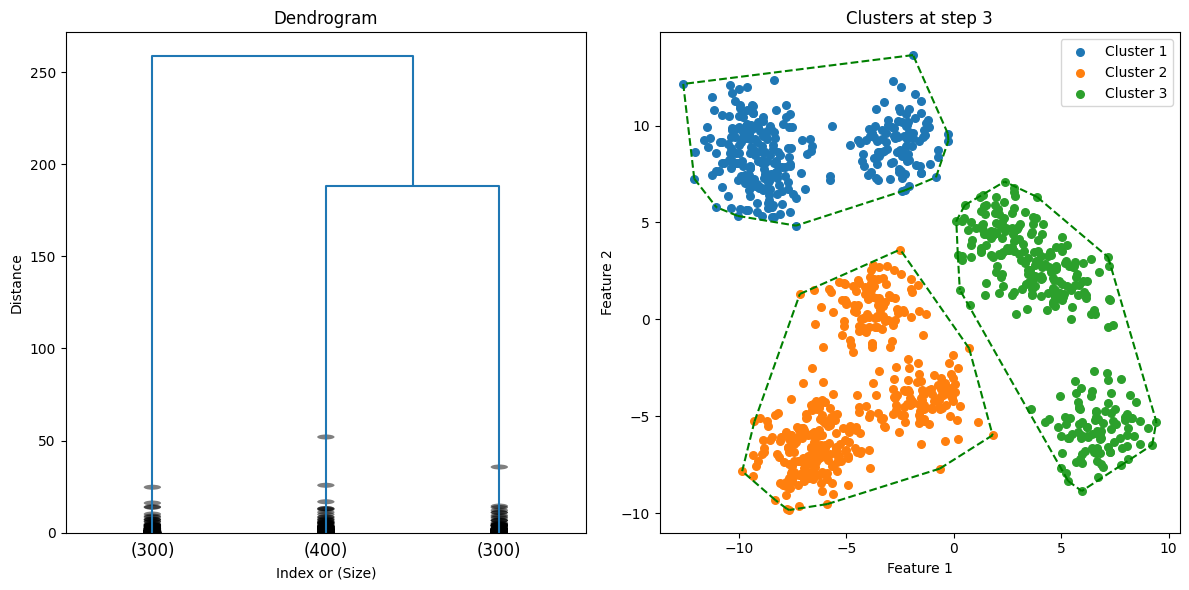

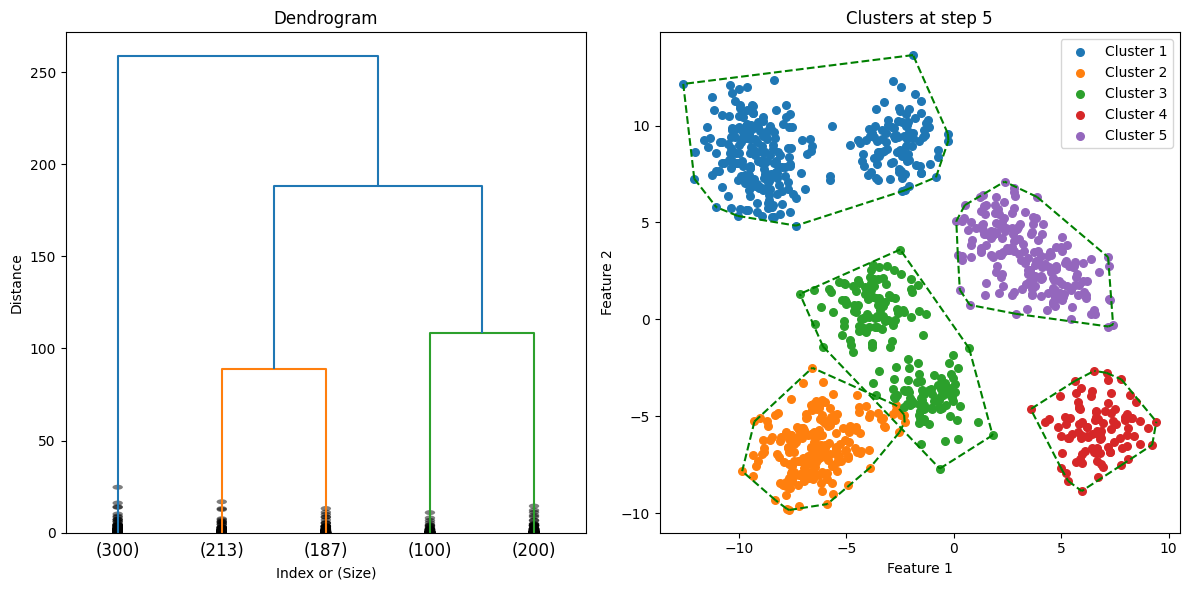

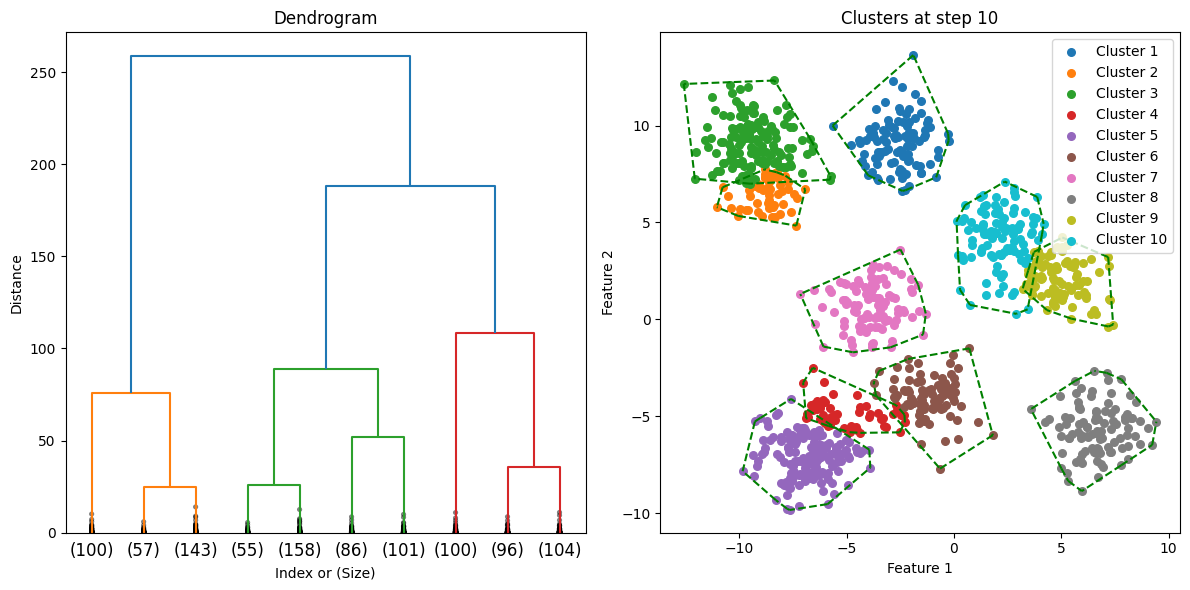

In [8]:
# Perform hierarchical clustering using the Ward method
linked = linkage(X, method='ward')

# Function to interactively plot clusters and dendrogram
def plot_clusters(num_clusters):
    plt.figure(figsize=(12, 6))  # Set figure size
    plt.subplot(1, 2, 1)  # Define the layout for the dendrogram
    dendrogram(linked, truncate_mode='lastp', p=num_clusters, show_contracted=True)  # Plot the dendrogram
    plt.title("Dendrogram")  # Title for the dendrogram
    plt.xlabel('Index or (Size)')  # X-axis label
    plt.ylabel('Distance')  # Y-axis label

    plt.subplot(1, 2, 2)  # Define the layout for the cluster plot
    # Determine the clusters based on the specified number of clusters
    labels = fcluster(linked, num_clusters, criterion='maxclust')
    unique_labels = np.unique(labels)  # Find unique cluster labels
    
    # Plot each cluster with a unique color and draw convex hulls
    for label in unique_labels:
        points = X[labels == label]  # Extract points belonging to the current cluster
        if points.shape[0] > 2:  # Draw convex hulls only if there are more than two points
            hull = ConvexHull(points)
            for simplex in hull.simplices:  # Draw lines between the vertices of the convex hull
                plt.plot(points[simplex, 0], points[simplex, 1], 'g--')
        plt.scatter(points[:, 0], points[:, 1], s=30, label=f'Cluster {label}')  # Plot cluster points
    
    plt.title(f'Clusters at step {num_clusters}')  # Title for the cluster plot
    plt.xlabel('Feature 1')  # X-axis label for cluster plot
    plt.ylabel('Feature 2')  # Y-axis label for cluster plot
    plt.legend()  # Show legend
    plt.tight_layout()  # Adjust layout
    plt.show()

# Interactive widget to choose the number of clusters
num_clusters_slider = widgets.IntSlider(min=1, max=20, step=1, value=5, description='Number of Clusters')
widgets.interactive(plot_clusters, num_clusters=num_clusters_slider)  # Create an interactive slider widget
plot_clusters(num_clusters=3)
plot_clusters(num_clusters=5)
plot_clusters(num_clusters=10)

## Hierarchical Clustering

This demonstrates hierarchical clustering using synthetic data, providing an interactive way to visualize the clustering process through dendrograms and convex hulls. Here’s how each part of the code contributes to the functionality:

### Hierarchical Clustering
- **`linkage`**: This function from `scipy.cluster.hierarchy` performs hierarchical/agglomerative clustering. The 'ward' method is specified, which minimizes the variance of the clusters being merged. This method is effective for creating more compact and balanced clusters.

- **`dendrogram`**: Visualizes the results of the linkage as a dendrogram, which provides a tree-like diagram of the merging clusters. It helps in understanding the sequence of cluster unions and the distance at which each union occurred.

### Interactive Visualization
- **Plotting Clusters with Convex Hulls**:
  - **`fcluster`**: Extracts cluster labels for a given number of clusters from the hierarchical clustering data. This function allows for dynamically choosing the number of clusters directly from the dendrogram.
  
  - **`ConvexHull`**: Calculates and plots convex hulls around the points in each cluster if the cluster has more than two points. Convex hulls are useful for visually encapsulating the extent of each cluster, emphasizing its coherence and separation from other clusters.
  - **Scatter Plot**: Displays the data points, color-coded by their cluster labels, which helps in visualizing the distribution and grouping of data points in two-dimensional space.

### Widgets
- **`IntSlider`**: Allows interactive selection of the number of clusters to display. Adjusting the slider dynamically updates the dendrogram and the scatter plot to reflect the chosen number of clusters.

## Divisive hierarchical clustering

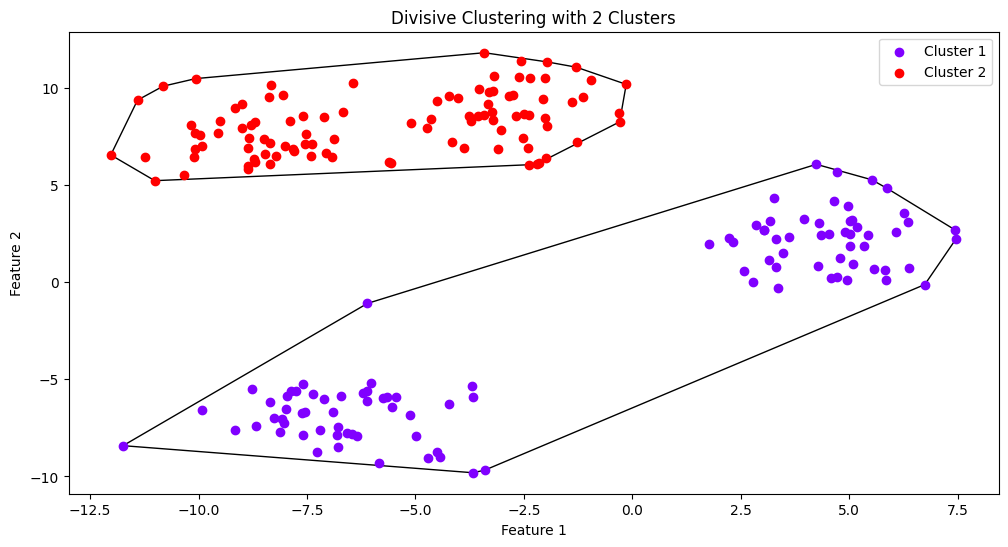

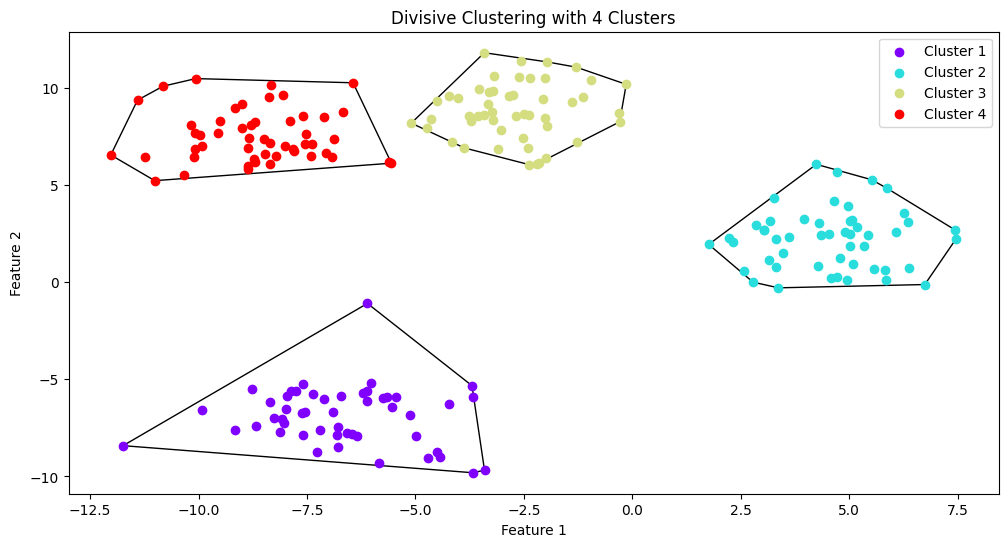

ValueError: operands could not be broadcast together with shapes (50,2) (51,2) 

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from scipy.spatial import ConvexHull
import ipywidgets as widgets
from IPython.display import display

# Generate synthetic data for clustering demonstration
X, _ = make_blobs(n_samples=200, centers=4, cluster_std=1.5, random_state=42)

# Function to perform divisive clustering
def divisive_clustering(X, num_clusters):
    labels = np.zeros(X.shape[0], dtype=int)  # Initialize labels for each point
    current_clusters = 1
    clusters = [X]  # Start with all points in one cluster

    # Loop to split clusters until the desired number of clusters is reached
    while len(clusters) < num_clusters:
        largest_cluster = max(clusters, key=len)  # Find the largest cluster
        clusters.remove(largest_cluster)  # Remove it from the cluster list

        # Use KMeans to split the largest cluster into two
        if len(largest_cluster) > 1:  # Ensure there are enough points to split
            kmeans = KMeans(n_clusters=2, random_state=42)
            new_labels = kmeans.fit_predict(largest_cluster)
            # Separate the split clusters based on labels
            cluster1 = largest_cluster[new_labels == 0]
            cluster2 = largest_cluster[new_labels == 1]
            clusters.append(cluster1)
            clusters.append(cluster2)
        else:
            clusters.append(largest_cluster)  # Add back if not splittable

    # Assign final labels for plotting
    final_labels = np.zeros(X.shape[0], dtype=int)
    for i, cluster in enumerate(clusters):
        for point in cluster:
            idx = np.where(X == point)[0][0]
            final_labels[idx] = i

    return final_labels

# Function to plot the results of divisive clustering
def plot_divisive(num_clusters):
    labels = divisive_clustering(X, num_clusters)
    plt.figure(figsize=(12, 6))
    unique_labels = np.unique(labels)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))

    # Plot each cluster with points and their convex hull
    for i, color in zip(unique_labels, colors):
        points = X[labels == i]
        hull = ConvexHull(points)
        plt.fill(points[hull.vertices, 0], points[hull.vertices, 1], edgecolor='k', fill=False)
        plt.scatter(points[:, 0], points[:, 1], color=color, label=f'Cluster {i+1}')

    plt.title(f'Divisive Clustering with {num_clusters} Clusters')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.show()

# Interactive widget to select the number of clusters
num_clusters_slider = widgets.IntSlider(min=2, max=10, step=1, value=4, description='Number of Clusters')
widgets.interactive(plot_divisive, num_clusters=num_clusters_slider)

plot_divisive(num_clusters=2)
plot_divisive(num_clusters=4)
plot_divisive(num_clusters=6)

## Divisive Clustering

This Python demonstrates an interactive visualization of divisive clustering, which is a "top-down" approach in hierarchical clustering. Here's a breakdown of its functionality:

- **Divisive Clustering Function**:
  - Initializes all data points in a single cluster.
  - Iteratively splits the largest cluster using `KMeans` clustering until the desired number of clusters is achieved.
  - Utilizes `KMeans` from `sklearn.cluster` to find two sub-clusters within the largest cluster at each step, ensuring a methodical division based on data similarity.

- **Visualization**:
  - For each cluster identified, plots data points and their convex hulls using `ConvexHull` from `scipy.spatial`, which helps to visually encapsulate the cluster boundaries.
  - Allows interactive exploration through an IPython widget slider, enabling the user to change the number of clusters dynamically and observe how the clustering structure changes.